# Instituto Tecnológico y de Estudios Superiores de Monterrey
## Escuela de Ingenierías  
## Maestría en Inteligencia Artificial Aplicada  
## Proyecto Integrador (TC5035 - Grupo 10)

---

# Avance 2 – Ingeniería de características
## Proyecto Integrador TC5035 – Grupo 28

**Integrantes del grupo:**

- Carolina Gómez Fernández – A01305369  
- Jorge Eduardo Reyes de la Rosa – A00282698  
- Enrique Jiménez Téllez – A01796026  

---

## Introducción

En esta fase de la metodología **CRISP-ML** se realiza la preparación avanzada de los datos mediante técnicas de **ingeniería de características** (*Feature Engineering*). El objetivo principal es transformar los datos originales en un conjunto de variables más representativas, útiles y adecuadas para modelos de aprendizaje automático.

El dataset utilizado contiene información académica y demográfica de estudiantes del curso **Fundamentos de Informática**, incluyendo variables relacionadas con:

- Rendimiento académico.
- Evaluaciones parciales.
- Procedencia estudiantil.
- Distancia aproximada.
- Sexo.
- Condición final del curso.

La aplicación de técnicas de ingeniería de características al dataset permitirá:

- Mejorar la calidad de los datos.
- Reducir ruido e inconsistencias.
- Facilitar el entrenamiento de modelos.
- Disminuir la complejidad computacional.
- Incrementar la capacidad predictiva.

Además, durante esta etapa se aplicarán técnicas de preprocesamiento y selección de características como codificación de variables categóricas, escalamiento de variables numéricas, análisis de correlación, selección estadística de variables y reducción de dimensionalidad mediante PCA. Estas técnicas buscan optimizar la calidad de los datos, reducir el riesgo de sobreajuste y evitar problemas de data leakage, garantizando una preparación adecuada para las siguientes etapas de modelado y evaluación.

## 0. Configuración inicial e importación de librerías

En este bloque se importan las librerías necesarias para el manejo de datos, procesamiento numérico, preparación del dataset y selección/extracción de características. También se incorporan herramientas de `scikit-learn` para construir un flujo reproducible de ingeniería de características.


In [ ]:
# ============================================================
# FEATURE ENGINEERING - DATASET FUNDAMENTOS DE INFORMÁTICA
# ============================================================

import pandas as pd
import numpy as np
import os

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, chi2
from sklearn.decomposition import PCA


## 1. Carga del dataset desde Google Drive

En este bloque se monta Google Drive y se define la ruta donde se encuentra el archivo limpio del proyecto. Este dataset corresponde al resultado del proceso de análisis exploratorio y limpieza realizado en el Avance 1, donde se corrigieron valores faltantes, se eliminaron variables redundantes y se definió la variable objetivo para clasificación. Posteriormente, se carga el dataset en un DataFrame de Pandas para iniciar la fase de preparación de datos.


In [ ]:
# ============================================================
# 1. MONTAR GOOGLE DRIVE
# ============================================================

drive.mount('/content/drive')

ruta_base = "/content/drive/MyDrive/Proyecto Integrador"
archivo = "Fundamentos_Informatica_EDA_limpio.csv"

ruta_archivo = os.path.join(ruta_base, archivo)

df = pd.read_csv(ruta_archivo)

print("Dimensiones iniciales:", df.shape)
display(df.head())


Mounted at /content/drive
Dimensiones iniciales: (1490, 11)


,Año_lectivo,Promedio de ingreso,Sexo,Grupo,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Distancia_km_final,Distancia_missing,Target_Reprobado
0,2020,708.48,M,1,0.0,0.00,0.0,47.43,18.0,0,1
1,2020,717.21,M,1,26.7,19.50,28.5,75.87,6.0,0,0
2,2020,702.27,M,1,16.5,15.60,88.0,52.56,69.0,0,1
3,2020,661.05,M,1,21.0,19.80,85.0,44.58,18.0,0,1
4,2020,768.96,F,1,21.9,29.25,100.0,87.67,6.8,0,0


## 2. Revisión inicial del dataset

Antes de aplicar técnicas de ingeniería de características, se realiza una revisión general del dataset para validar su integridad y comprender la estructura de las variables disponibles.

En esta etapa se analizan:

- Las columnas disponibles y su significado general.
- Los tipos de datos de cada variable.
- La presencia de valores faltantes.
- La distribución de la variable objetivo (`Target_Reprobado`).

Esta revisión permite:

- Verificar que el dataset fue cargado correctamente.
- Identificar posibles problemas de calidad de datos.
- Determinar qué variables requieren transformación o codificación.
- Definir las estrategias de preprocesamiento necesarias para las siguientes etapas.

De forma adicional, se confirma que el dataset no presenta valores nulos y que la variable objetivo presenta una distribución relativamente balanceada, aunque con una ligera mayor proporción de estudiantes reprobados.


In [ ]:

# ============================================================
# 2. REVISIÓN INICIAL
# ============================================================

print("\nColumnas del dataset:")
print(df.columns.tolist())

print("\nInformación general:")
print(df.info())

print("\nValores faltantes:")
print(df.isna().sum())

print("\nDistribución del target:")
print(df["Target_Reprobado"].value_counts(normalize=True) * 100)


Columnas del dataset:
['Año_lectivo', 'Promedio de ingreso', 'Sexo', 'Grupo', 'Evaluación_1', 'Evaluación_2', 'Evaluación_3', 'Tareas_y_Pruebas_Cortas', 'Distancia_km_final', 'Distancia_missing', 'Target_Reprobado']

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Año_lectivo              1490 non-null   int64  
 1   Promedio de ingreso      1490 non-null   float64
 2   Sexo                     1490 non-null   object 
 3   Grupo                    1490 non-null   int64  
 4   Evaluación_1             1490 non-null   float64
 5   Evaluación_2             1490 non-null   float64
 6   Evaluación_3             1490 non-null   float64
 7   Tareas_y_Pruebas_Cortas  1490 non-null   float64
 8   Distancia_km_final       1490 non-null   float64
 9   Distancia_missing        1490 non-null   int64  
 10  T

## 3. Generación de nuevas características académicas


En esta etapa se construyen nuevas variables derivadas a partir de las evaluaciones parciales y actividades académicas. El objetivo es representar de mejor manera el comportamiento y desempeño de los estudiantes mediante características más informativas para los modelos de aprendizaje automático.

Las nuevas variables generadas incluyen:

- `Promedio_Evaluaciones`: resume el desempeño promedio de las evaluaciones parciales.
- `Desviacion_Evaluaciones`: mide la variabilidad entre evaluaciones, permitiendo identificar estudiantes con desempeño inconsistente.
- `Diferencia_Eval3_Eval1`: captura tendencias de mejora o deterioro académico a lo largo del curso.
- `Total_Actividades`: integra el desempeño acumulado considerando evaluaciones y tareas.
- `Ratio_Tareas_vs_Evaluaciones`: representa la relación entre desempeño en tareas y evaluaciones formales.

Estas características permiten enriquecer de cierta forma la representación del dataset y proporcionar información adicional que podría mejorar la capacidad predictiva de los modelos.


In [ ]:
# ============================================================
# 3. FEATURE ENGINEERING: NUEVAS VARIABLES
# ============================================================

evaluaciones = ["Evaluación_1", "Evaluación_2", "Evaluación_3"]

df["Promedio_Evaluaciones"] = df[evaluaciones].mean(axis=1)

df["Desviacion_Evaluaciones"] = df[evaluaciones].std(axis=1)

df["Diferencia_Eval3_Eval1"] = df["Evaluación_3"] - df["Evaluación_1"]

df["Total_Actividades"] = (
    df["Evaluación_1"].fillna(0) +
    df["Evaluación_2"].fillna(0) +
    df["Evaluación_3"].fillna(0) +
    df["Tareas_y_Pruebas_Cortas"].fillna(0)
)

df["Ratio_Tareas_vs_Evaluaciones"] = (
    df["Tareas_y_Pruebas_Cortas"] /
    (df["Promedio_Evaluaciones"] + 1)
)

df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
df["Distancia_km_final"].describe()

,Distancia_km_final
count,1490.000000
mean,33.071275
std,53.088892
min,0.000000
25%,4.800000
50%,10.600000
75%,35.000000
max,395.000000


In [ ]:

df["Promedio de ingreso"].describe()

,Promedio de ingreso
count,1490.000000
mean,714.234987
std,43.708822
min,620.190000
25%,683.730000
50%,708.480000
75%,738.360000
max,900.000000


<Axes: >

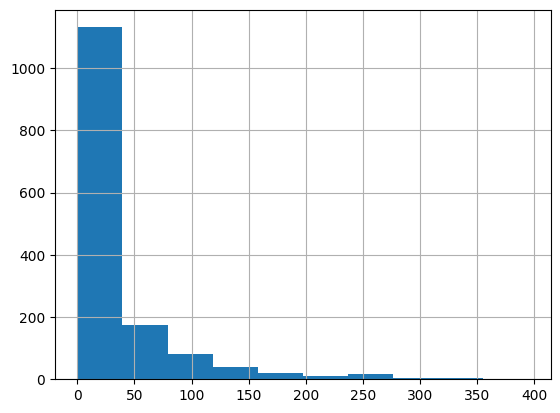

In [ ]:
df["Distancia_km_final"].hist()

<Axes: >

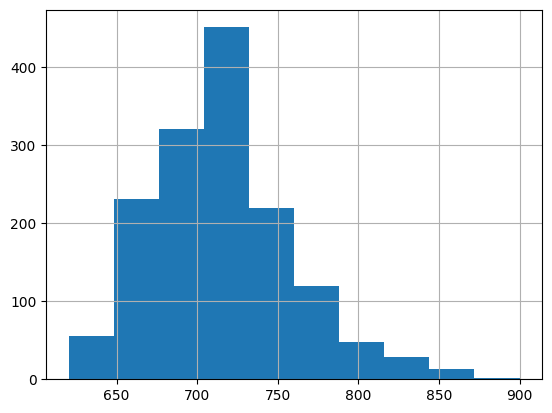

In [ ]:

df["Promedio de ingreso"].hist()

## 4. Discretización o *binning* de variables continuas

La discretización nos permite transformar variables numéricas continuas en categorías interpretables. Esta técnica ayuda a reducir la sensibilidad a valores extremos, facilitar el análisis de patrones y mejorar el desempeño de algunos algoritmos de aprendizaje automático.

En esta etapa generamos nuevas variables categóricas a partir de:

- La distancia aproximada del estudiante (`Distancia_km_final`).
- El promedio de ingreso (`Promedio de ingreso`).

Para ello se agrupan los valores en distintos niveles representativos mediante intervalos definidos previamente. Esto permite representar de forma más sencilla características demográficas y académicas que podrían influir en el desempeño final de los estudiantes.


In [ ]:
# ============================================================
# 4. BINNING / DISCRETIZACIÓN
# ============================================================


df["Nivel_Distancia"] = pd.qcut(
    df["Distancia_km_final"],
    q=4,
    labels=["Muy_cerca", "Cerca", "Media", "Lejos"]
)

df["Nivel_Promedio_Ingreso"] = pd.cut(
    df["Promedio de ingreso"],
    bins=[600, 680, 710, 740, 800, np.inf],
    labels=["Muy_bajo", "Bajo", "Medio", "Alto", "Muy_alto"]
)






## 5. Transformación logarítmica y separación de variables predictoras

En esta etapa se aplica una transformación logarítmica sobre la variable `Distancia_km_final` con el objetivo de reducir el sesgo generado por valores extremos y mejorar la distribución de la variable.

La transformación logarítmica permite:

- Disminuir el impacto de valores atípicos.
- Reducir asimetrías en la distribución.
- Facilitar el proceso de escalamiento posterior.
- Mejorar el desempeño de algunos algoritmos de aprendizaje automático.

Posteriormente, se separan las variables predictoras (`X`) y la variable objetivo (`y`) para preparar el dataset para el proceso de entrenamiento supervisado.

In [ ]:



# ============================================================
# 5. TRANSFORMACIÓN LOGARÍTMICA
# ============================================================

df["Log_Distancia"] = np.log1p(df["Distancia_km_final"])

# ============================================================
# 6. SEPARACIÓN DE VARIABLES PREDICTORAS Y TARGET
# ============================================================

X = df.drop(columns=["Target_Reprobado"])
y = df["Target_Reprobado"]


## 6. División del dataset en entrenamiento y prueba

El dataset se divide en conjuntos de entrenamiento y prueba antes de aplicar procesos de imputación, escalamiento o selección de características. Esta estrategia permite evitar fuga de información (*data leakage*), garantizando que la información del conjunto de prueba no influya durante el entrenamiento del modelo.

Se utiliza una división estratificada (`stratify`) para conservar la proporción original de clases de la variable objetivo en ambos subconjuntos.

Finalmente, se utiliza:

- 80% de los datos para entrenamiento.
- 20% de los datos para prueba.



In [ ]:

# ============================================================
# 7. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain:", X_train.shape)
print("Test:", X_test.shape)



Train: (1192, 18)
Test: (298, 18)


## 7. Identificación de variables numéricas y categóricas

En esta etapa se identifican automáticamente las variables numéricas y categóricas presentes en el conjunto de entrenamiento. Esta separación es necesaria para aplicar estrategias de preprocesamiento específicas según el tipo de dato.

Las variables numéricas requieren procesos como:

- imputación de valores faltantes,
- escalamiento,
- normalización,
- y selección estadística.

Por otro lado, las variables categóricas requieren:

- imputación de categorías faltantes,
- codificación mediante técnicas como One-Hot Encoding,
- y manejo de categorías no observadas.

Realizar esta separación de manera automátican nos ayuda a mejorar la flexibilidad y reproducibilidad del pipeline de preparación de datos.


In [ ]:
# ============================================================
# 8. IDENTIFICACIÓN DE VARIABLES
# ============================================================

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("\nVariables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)



Variables numéricas:
['Año_lectivo', 'Promedio de ingreso', 'Grupo', 'Evaluación_1', 'Evaluación_2', 'Evaluación_3', 'Tareas_y_Pruebas_Cortas', 'Distancia_km_final', 'Distancia_missing', 'Promedio_Evaluaciones', 'Desviacion_Evaluaciones', 'Diferencia_Eval3_Eval1', 'Total_Actividades', 'Ratio_Tareas_vs_Evaluaciones', 'Log_Distancia']

Variables categóricas:
['Sexo', 'Nivel_Distancia', 'Nivel_Promedio_Ingreso']


## 8. Construcción de pipelines de preprocesamiento

Se construyen pipelines independientes para variables numéricas y categóricas con el objetivo de automatizar el proceso de preparación de datos y garantizar reproducibilidad durante el entrenamiento de modelos.

### Pipeline numérico

Para las variables numéricas se aplican las siguientes transformaciones:

- Imputación de valores faltantes mediante la mediana.
- Escalamiento utilizando `StandardScaler`.

La mediana fue seleccionada debido a su robustez frente a valores extremos, mientras que el escalamiento permite que todas las variables tengan una magnitud comparable y evita que algunas dominen el entrenamiento del modelo.

### Pipeline categórico

Para las variables categóricas se aplican:

- Imputación de categorías faltantes utilizando el valor `"Desconocido"`.
- Codificación mediante `OneHotEncoder`.

La codificación One-Hot permite transformar variables categóricas en representaciones numéricas compatibles con algoritmos de aprendizaje automático.

Finalmente, ambos pipelines se integran mediante `ColumnTransformer`, permitiendo aplicar automáticamente las transformaciones correspondientes a cada tipo de variable de manera ordenada y reproducible.


In [ ]:
# ============================================================
# 9. PIPELINES DE PREPROCESAMIENTO
# ============================================================

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Desconocido")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


## 9. Aplicación del preprocesamiento

Durante esta etapa aplicamos el pipeline de preprocesamiento utilizando únicamente el conjunto de entrenamiento (`X_train`). Posteriormente, las mismas transformaciones aprendidas se aplican al conjunto de prueba (`X_test`).

Esto nos ayuda para evitar fuga de información (*data leakage*), ya que permite que estadísticas como medias, medianas, escalamiento y categorías codificadas sean calculadas exclusivamente a partir de los datos de entrenamiento.

Durante este proceso se ejecutan las siguientes operaciones:

- Imputación de valores faltantes.
- Escalamiento de variables numéricas.
- Codificación One-Hot para variables categóricas.
- Construcción automática del conjunto final de variables transformadas.

Después del preprocesamiento, el número de variables aumenta debido a la codificación de variables categóricas mediante One-Hot Encoding.



In [ ]:
# ============================================================
# 10. APLICAR PREPROCESAMIENTO
# ============================================================

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

cat_names = preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features)
feature_names = numeric_features + cat_names.tolist()

X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)

print("\nDespués de imputación, encoding y scaling:")
print("Train:", X_train_processed_df.shape)
print("Test:", X_test_processed_df.shape)



Después de imputación, encoding y scaling:
Train: (1192, 27)
Test: (298, 27)


## 10. Selección por umbral de varianza

Se aplicó la técnica `VarianceThreshold` con el objetivo de identificar variables con muy baja variabilidad, ya que este tipo de características suele aportar poca información al modelo y puede incrementar innecesariamente la dimensionalidad.

El método fue ajustado utilizando únicamente el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

En este caso, después de aplicar el umbral de varianza (`threshold = 0.01`), no se eliminaron variables, lo que indica que todas las características conservadas presentan un nivel mínimo de variabilidad y potencialmente aportan información útil para el modelado.

Aunque no se redujo la dimensionalidad en esta etapa, la aplicación del método permitió validar que las variables generadas y transformadas poseen suficiente dispersión estadística para continuar en el proceso de selección y extracción de características.


In [ ]:
# ============================================================
# 11. SELECCIÓN POR UMBRAL DE VARIANZA
# ============================================================

var_selector = VarianceThreshold(threshold=0.01)

X_train_var = var_selector.fit_transform(X_train_processed_df)
X_test_var = var_selector.transform(X_test_processed_df)

features_var = X_train_processed_df.columns[var_selector.get_support()]

X_train_var_df = pd.DataFrame(X_train_var, columns=features_var)
X_test_var_df = pd.DataFrame(X_test_var, columns=features_var)

print("\nDespués de VarianceThreshold:")
print(X_train_var_df.shape)



Después de VarianceThreshold:
(1192, 26)


## 11. Eliminación de variables altamente correlacionadas

Aquí aplicamos  un proceso de selección de características basado en correlación con el objetivo de reducir redundancia y disminuir problemas de multicolinealidad entre variables predictoras.

Para ello, calculamos la matriz de correlación absoluta utilizando únicamente el conjunto de entrenamiento y se eliminaron variables con correlación superior a `0.90`.

La eliminación de variables altamente correlacionadas nos permite:

- reducir complejidad del modelo,
- disminuir redundancia de información,
- mejorar interpretabilidad,
- y evitar que ciertas variables dominen el entrenamiento debido a información duplicada.

Como resultado, se eliminaron las siguientes variables:

- `Total_Actividades`
- `Sexo_M`

La variable `Total_Actividades` presentó alta correlación con otras variables académicas derivadas, ya que representa una combinación de múltiples evaluaciones. Por otro lado, `Sexo_M` fue eliminada debido a redundancia generada por el proceso de codificación One-Hot Encoding.



In [ ]:
# ============================================================
# 12. ELIMINACIÓN POR ALTA CORRELACIÓN
# ============================================================

def eliminar_correlacion_alta(X_train_df, X_test_df, threshold=0.90):
    corr_matrix = X_train_df.corr().abs()

    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    columnas_a_eliminar = [
        column for column in upper.columns
        if any(upper[column] > threshold)
    ]

    X_train_reducido = X_train_df.drop(columns=columnas_a_eliminar)
    X_test_reducido = X_test_df.drop(columns=columnas_a_eliminar)

    return X_train_reducido, X_test_reducido, columnas_a_eliminar

X_train_corr_df, X_test_corr_df, columnas_corr_eliminadas = eliminar_correlacion_alta(
    X_train_var_df,
    X_test_var_df,
    threshold=0.90
)

print("\nColumnas eliminadas por alta correlación:")
print(columnas_corr_eliminadas)

print("\nDespués de eliminar correlaciones altas:")
print(X_train_corr_df.shape)



Columnas eliminadas por alta correlación:
['Total_Actividades', 'Sexo_M']

Después de eliminar correlaciones altas:
(1192, 24)


## 12. Selección de características mediante ANOVA


Se aplicó selección de características mediante ANOVA (`f_classif`) con el objetivo de identificar las variables con mayor relación estadística respecto a la variable objetivo `Target_Reprobado`.

Esta técnica permite medir qué tan relevantes son las características numéricas para diferenciar entre estudiantes aprobados y reprobados.

La selección se realizó utilizando únicamente el conjunto de entrenamiento para evitar fuga de información (*data leakage*). Posteriormente, las mismas transformaciones fueron aplicadas al conjunto de prueba.

Se seleccionaron las variables con mayor puntuación estadística (`ANOVA Score`), conservando aquellas con mayor capacidad predictiva.

Los resultados mostraron que las variables más relevantes fueron:

- `Promedio_Evaluaciones`
- `Evaluación_2`
- `Evaluación_1`
- `Evaluación_3`
- `Tareas_y_Pruebas_Cortas`

Esto confirma que el desempeño académico parcial tiene una relación directa y significativa con la probabilidad de reprobación final.

Adicionalmente, variables como:

- `Promedio de ingreso`
- `Año_lectivo`
- `Ratio_Tareas_vs_Evaluaciones`

también presentaron cierta capacidad predictiva, aunque con menor relevancia.

Por otro lado, variables relacionadas con distancia (`Log_Distancia` y categorías de distancia) obtuvieron puntuaciones bajas, indicando una relación limitada con la variable objetivo en este conjunto de datos.

La aplicación de ANOVA permitió reducir dimensionalidad y conservar únicamente las variables más informativas para etapas posteriores de modelado.

Los resultados obtenidos mediante ANOVA evidenciaron que las evaluaciones parciales y el promedio de evaluaciones son las variables con mayor relación respecto a la reprobación final, confirmando que el desempeño académico continuo es el principal indicador predictivo dentro del dataset.


In [ ]:

# ============================================================
# 13. SELECCIÓN CON ANOVA
# ============================================================

k_anova = min(15, X_train_corr_df.shape[1])

anova_selector = SelectKBest(score_func=f_classif, k=k_anova)

X_train_anova = anova_selector.fit_transform(X_train_corr_df, y_train)
X_test_anova = anova_selector.transform(X_test_corr_df)

features_anova = X_train_corr_df.columns[anova_selector.get_support()]

anova_scores = pd.DataFrame({
    "Feature": X_train_corr_df.columns,
    "ANOVA_Score": anova_selector.scores_
}).sort_values(by="ANOVA_Score", ascending=False)

print("\nTop variables por ANOVA:")
display(anova_scores.head(15))



Top variables por ANOVA:


,Feature,ANOVA_Score
9,Promedio_Evaluaciones,1039.018636
4,Evaluación_2,851.303458
3,Evaluación_1,556.012485
5,Evaluación_3,442.866510
6,Tareas_y_Pruebas_Cortas,296.499275
1,Promedio de ingreso,59.142079
12,Ratio_Tareas_vs_Evaluaciones,47.551410
0,Año_lectivo,39.378949
11,Diferencia_Eval3_Eval1,31.607897
22,Nivel_Promedio_Ingreso_Muy_alto,22.037566


## 13. Selección de variables categóricas con Chi-cuadrado


Se aplicó selección de características mediante la prueba de Chi-cuadrado (`chi2`) con el objetivo de evaluar la relación entre variables categóricas codificadas y la variable objetivo `Target_Reprobado`.

Esta técnica permite identificar qué categorías presentan mayor dependencia estadística respecto al resultado final del estudiante.

La evaluación se realizó únicamente utilizando el conjunto de entrenamiento para evitar fuga de información (*data leakage*).

Los resultados mostraron que las variables categóricas poseen menor capacidad predictiva en comparación con las variables académicas numéricas analizadas previamente mediante ANOVA.

Entre las variables categóricas evaluadas, las más relevantes fueron:

- `Nivel_Promedio_Ingreso_Muy_alto`
- `Nivel_Proemdio_Ingreso_Muy_bajo`
- `Nivel_Promedio_Ingreso_Alto`

Sin embargo, sus puntuaciones fueron considerablemente menores respecto a las obtenidas por variables académicas como:

- `Promedio_Evaluaciones`
- `Evaluación_1`
- `Evaluación_2`
- `Evaluación_3`

Esto sugiere que el desempeño académico parcial tiene una influencia mucho más fuerte sobre la probabilidad de reprobación que factores demográficos o de distancia.

Adicionalmente, algunas categorías presentaron puntuaciones cercanas a cero, indicando una relación estadística mínima con la variable objetivo.

El aplicar Chi-cuadrado permitió complementar el proceso de selección de características y validar cuáles variables categóricas aportan información útil para etapas posteriores de modelado.

Las variables relacionadas con distancia y algunas categorías demográficas mostraron menor capacidad explicativa en comparación con las variables académicas, lo que sugiere que el rendimiento estudiantil depende principalmente del desempeño continuo en evaluaciones y actividades del curso.

In [ ]:
# ============================================================
# 14. SELECCIÓN CON CHI-CUADRADO
# ============================================================

cat_cols_after_encoding = [
    col for col in X_train_processed_df.columns
    if any(col.startswith(cat + "_") for cat in categorical_features)
]

if len(cat_cols_after_encoding) > 0:

    X_train_chi = X_train_processed_df[cat_cols_after_encoding]

    k_chi = min(10, X_train_chi.shape[1])

    chi_selector = SelectKBest(score_func=chi2, k=k_chi)
    chi_selector.fit(X_train_chi, y_train)

    chi_scores = pd.DataFrame({
        "Feature": X_train_chi.columns,
        "Chi2_Score": chi_selector.scores_
    }).sort_values(by="Chi2_Score", ascending=False)

    print("\nTop variables categóricas por Chi-cuadrado:")
    display(chi_scores.head(10))

else:
    print("\nNo hay variables categóricas para Chi-cuadrado.")


Top variables categóricas por Chi-cuadrado:


,Feature,Chi2_Score
10,Nivel_Promedio_Ingreso_Muy_alto,20.655032
11,Nivel_Promedio_Ingreso_Muy_bajo,13.634529
7,Nivel_Promedio_Ingreso_Alto,11.859763
8,Nivel_Promedio_Ingreso_Bajo,7.514956
9,Nivel_Promedio_Ingreso_Medio,3.730089
6,Nivel_Distancia_Muy_cerca,3.528478
5,Nivel_Distancia_Media,1.795091
4,Nivel_Distancia_Lejos,0.573318
1,Sexo_F,0.511923
2,Sexo_M,0.172233


## 14. Extracción de características mediante PCA

Aplicamos Análisis de Componentes Principales (PCA, *Principal Component Analysis*) con el objetivo de reducir la dimensionalidad del dataset y conservar la mayor cantidad posible de información relevante.

El PCA se configuró para conservar el 95% de la varianza explicada del conjunto de entrenamiento. Esta técnica transforma las variables originales en componentes no correlacionados que concentran la mayor variabilidad de los datos.

La transformación fue ajustada únicamente con el conjunto de entrenamiento para evitar fuga de información (*data leakage*), y posteriormente aplicada al conjunto de prueba.

Los resultados mostraron que fueron necesarios 14 componentes principales para conservar aproximadamente el 95% de la varianza total del dataset.

Esto indica que, aunque existía cierta redundancia entre variables, una parte importante de las características originales aún aportaba información relevante al modelo.

La reducción obtenida fue moderada, lo cual sugiere que el dataset contiene múltiples variables con información complementaria y no completamente redundante.

La aplicación de PCA permitió explorar una representación alternativa más compacta del conjunto de datos, útil para reducir complejidad computacional y analizar la estructura global de las variables.



In [ ]:

# ============================================================
# 15. PCA - REDUCCIÓN DE DIMENSIONALIDAD
# ============================================================

pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_corr_df)
X_test_pca = pca.transform(X_test_corr_df)

print("\nComponentes PCA necesarios para conservar 95% de varianza:")
print(pca.n_components_)

print("\nVarianza explicada acumulada:")
print(np.sum(pca.explained_variance_ratio_))



Componentes PCA necesarios para conservar 95% de varianza:
14

Varianza explicada acumulada:
0.9617860681922927


## 15. Construcción del dataset final para modelado

Se construyen los datasets finales de entrenamiento y prueba utilizando las variables seleccionadas mediante ANOVA. Estos conjuntos quedan listos para entrenar y evaluar modelos de clasificación supervisada.


In [ ]:
# ============================================================
# 16. DATASET FINAL PARA MODELADO
# ============================================================

X_train_final = pd.DataFrame(X_train_anova, columns=features_anova)
X_test_final = pd.DataFrame(X_test_anova, columns=features_anova)

X_train_final["Target_Reprobado"] = y_train.reset_index(drop=True)
X_test_final["Target_Reprobado"] = y_test.reset_index(drop=True)

print("\nDataset final train:")
print(X_train_final.shape)

print("\nDataset final test:")
print(X_test_final.shape)

display(X_train_final.head())


Dataset final train:
(1192, 16)

Dataset final test:
(298, 16)


,Año_lectivo,Promedio de ingreso,Evaluación_1,Evaluación_2,Evaluación_3,Tareas_y_Pruebas_Cortas,Promedio_Evaluaciones,Desviacion_Evaluaciones,Diferencia_Eval3_Eval1,Ratio_Tareas_vs_Evaluaciones,Nivel_Distancia_Muy_cerca,Nivel_Promedio_Ingreso_Alto,Nivel_Promedio_Ingreso_Bajo,Nivel_Promedio_Ingreso_Muy_alto,Nivel_Promedio_Ingreso_Muy_bajo,Target_Reprobado
0,-1.547406,1.815152,-0.271123,-1.300449,0.625233,1.985579,-0.240928,1.193730,0.913813,0.587437,1.0,1.0,0.0,0.0,0.0,1
1,0.222189,-1.140500,0.365479,0.015388,1.019268,-0.507075,0.641470,0.567877,0.876248,-0.443776,0.0,0.0,0.0,0.0,1.0,1
2,-0.367676,0.930930,0.458188,-1.095763,0.812711,0.822483,0.172526,1.284042,0.571968,-0.015749,0.0,1.0,0.0,0.0,0.0,1
3,1.401919,-1.447608,-0.716126,0.161592,-0.959205,-0.357686,-0.666482,0.015830,-0.541848,-0.049357,0.0,0.0,0.0,0.0,1.0,1
4,1.401919,2.192338,1.539792,1.565151,1.205917,0.472487,1.684493,-0.582136,0.195374,-0.372890,0.0,0.0,0.0,1.0,0.0,0


## 16. Exportación de datasets finales

En este bloque se guardan los conjuntos finales de entrenamiento y prueba en archivos CSV. Esto permite reutilizarlos en fases posteriores del proyecto, especialmente en la etapa de modelado.


In [ ]:

# ============================================================
# 17. GUARDAR DATASETS FINALES
# ============================================================

ruta_train = os.path.join(ruta_base, "dataset_train_feature_engineering.csv")
ruta_test = os.path.join(ruta_base, "dataset_test_feature_engineering.csv")

X_train_final.to_csv(ruta_train, index=False)
X_test_final.to_csv(ruta_test, index=False)

print("\nArchivos guardados:")
print(ruta_train)
print(ruta_test)



Archivos guardados:
/content/drive/MyDrive/Proyecto Integrador/dataset_train_feature_engineering.csv
/content/drive/MyDrive/Proyecto Integrador/dataset_test_feature_engineering.csv


## 17. Exportación de datasets con PCA

Además del dataset interpretable basado en variables seleccionadas, se guarda una versión reducida mediante PCA. Esta versión puede ser útil para modelos donde se priorice eficiencia computacional sobre interpretabilidad.


In [ ]:
# ============================================================
# 18. GUARDAR DATASETS PCA OPCIONALES
# ============================================================

pca_columns = [f"PC{i+1}" for i in range(X_train_pca.shape[1])]

train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns)
test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns)

train_pca_df["Target_Reprobado"] = y_train.reset_index(drop=True)
test_pca_df["Target_Reprobado"] = y_test.reset_index(drop=True)

ruta_train_pca = os.path.join(ruta_base, "dataset_train_pca.csv")
ruta_test_pca = os.path.join(ruta_base, "dataset_test_pca.csv")

train_pca_df.to_csv(ruta_train_pca, index=False)
test_pca_df.to_csv(ruta_test_pca, index=False)

print("\nArchivos PCA guardados:")
print(ruta_train_pca)
print(ruta_test_pca)


Archivos PCA guardados:
/content/drive/MyDrive/Proyecto Integrador/dataset_train_pca.csv
/content/drive/MyDrive/Proyecto Integrador/dataset_test_pca.csv


## 18. Resumen de la fase de ingeniería de características

Finalmente, presentamos un resumen de las principales transformaciones aplicadas durante la fase de ingeniería de características y preparación avanzada de datos.

La tabla indica:

- Las etapas ejecutadas dentro del pipeline.
- La evolución en el número de variables.
- Las técnicas de selección y extracción aplicadas.
- La justificación metodológica de cada transformación.

Este resumen permite documentar de manera estructurada el flujo completo de preparación de datos dentro del contexto de la metodología CRISP-ML, mostrando cómo el dataset evolucionó desde un conjunto inicial de variables hasta representaciones optimizadas para modelado.

Los resultados evidencian que:

- Se generaron nuevas variables académicas derivadas.
- Se aplicaron procesos de imputación, codificación y escalamiento.
- Se redujo redundancia mediante eliminación de variables correlacionadas.
- Se seleccionaron variables relevantes utilizando ANOVA y Chi-cuadrado.
- Se exploró reducción de dimensionalidad mediante PCA conservando el 95% de la varianza explicada.

La tabla final facilita la interpretación del impacto de cada etapa sobre la complejidad y representatividad del conjunto de datos.


In [ ]:




# ============================================================
# 19. RESUMEN PARA REPORTE
# ============================================================

resumen = pd.DataFrame({
    "Etapa": [
        "Dataset original",
        "Después de Feature Engineering",
        "Después de imputación, encoding y scaling",
        "Después de umbral de varianza",
        "Después de eliminación por correlación",
        "Después de selección ANOVA",
        "Después de PCA"
    ],
    "Número de variables": [
        df.shape[1],
        X.shape[1],
        X_train_processed_df.shape[1],
        X_train_var_df.shape[1],
        X_train_corr_df.shape[1],
        X_train_final.shape[1] - 1,
        pca.n_components_
    ],
    "Justificación": [
        "Dataset limpio con variable objetivo definida.",
        "Se crearon variables académicas, discretizaciones y transformaciones.",
        "Se imputaron faltantes, codificaron categóricas y escalaron numéricas.",
        "Se eliminaron variables con baja variabilidad.",
        "Se redujo redundancia eliminando variables altamente correlacionadas.",
        "Se seleccionaron las variables más relacionadas con la reprobación.",
        "Se redujo dimensionalidad conservando 95% de la varianza."
    ]
})

display(resumen)

ruta_resumen = os.path.join(ruta_base, "resumen_feature_engineering.csv")
resumen.to_csv(ruta_resumen, index=False)

print("\nResumen guardado en:")
print(ruta_resumen)

,Etapa,Número de variables,Justificación
0,Dataset original,19,Dataset limpio con variable objetivo definida.
1,Después de Feature Engineering,18,"Se crearon variables académicas, discretizacio..."
2,"Después de imputación, encoding y scaling",27,"Se imputaron faltantes, codificaron categórica..."
3,Después de umbral de varianza,26,Se eliminaron variables con baja variabilidad.
4,Después de eliminación por correlación,24,Se redujo redundancia eliminando variables alt...
5,Después de selección ANOVA,15,Se seleccionaron las variables más relacionada...
6,Después de PCA,14,Se redujo dimensionalidad conservando 95% de l...



Resumen guardado en:
/content/drive/MyDrive/Proyecto Integrador/resumen_feature_engineering.csv


## 19. Visualización de la preparación de datos

Para complementar la fase de ingeniería de características, se incorporan gráficas que permiten observar visualmente el efecto de las transformaciones aplicadas. La primera gráfica muestra cómo cambia el número de variables a lo largo de las etapas de preparación, desde el dataset original hasta la selección y extracción de características. La segunda gráfica muestra la varianza explicada acumulada por PCA, lo que ayuda a justificar cuántos componentes son necesarios para conservar la mayor parte de la información del dataset.


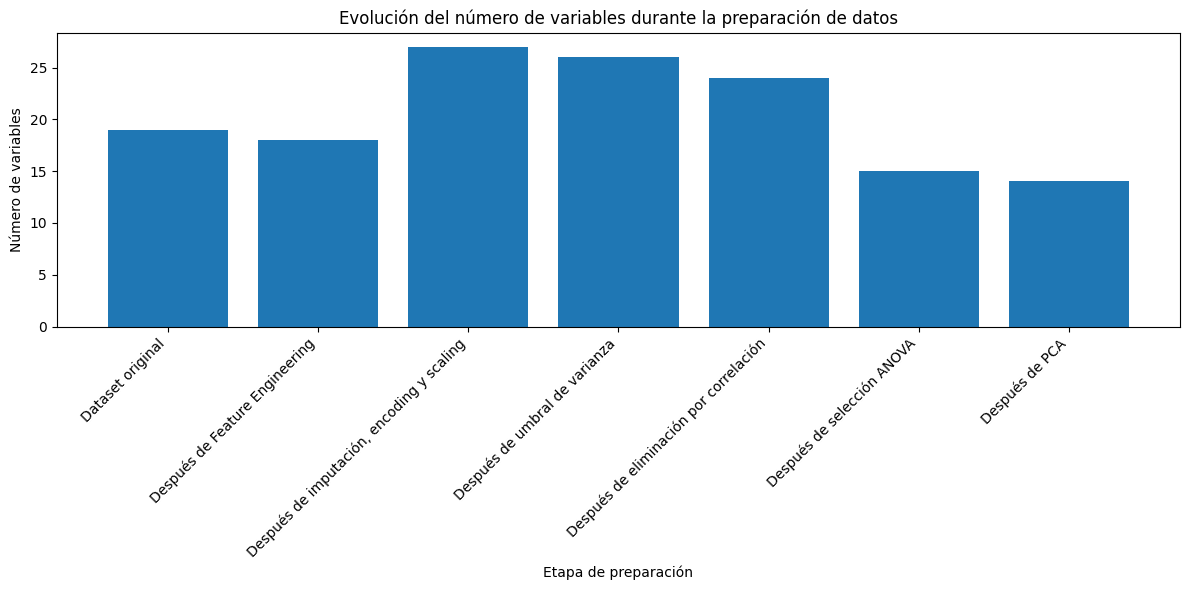

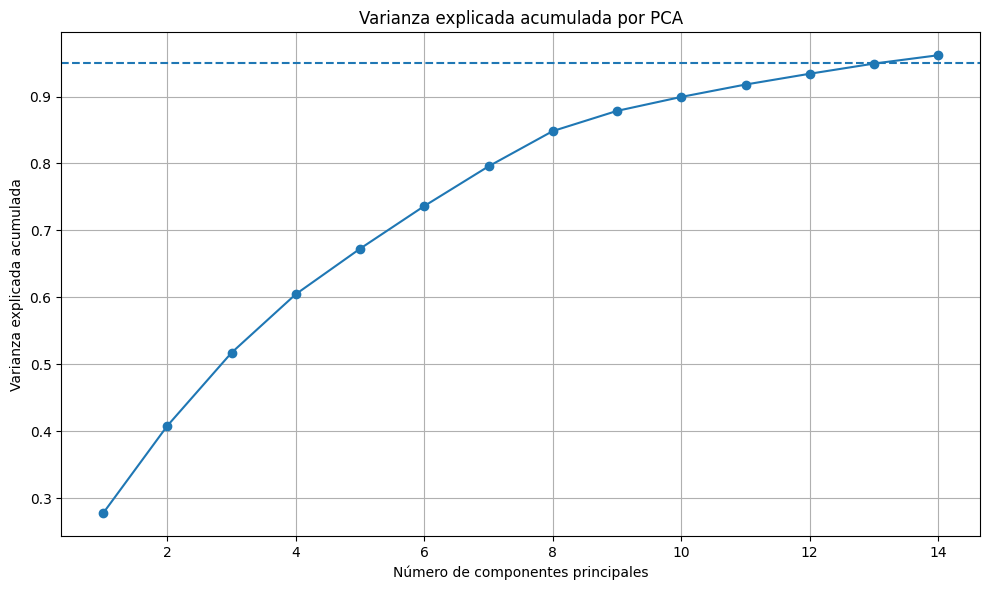

In [ ]:
# ============================================================
# 20. GRÁFICAS DE APOYO PARA LA PREPARACIÓN DE DATOS
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Gráfica 1: Número de variables por etapa de preparación
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))
plt.bar(resumen["Etapa"], resumen["Número de variables"])
plt.title("Evolución del número de variables durante la preparación de datos")
plt.xlabel("Etapa de preparación")
plt.ylabel("Número de variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Gráfica 2: Varianza explicada acumulada por PCA
# ------------------------------------------------------------

varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(y=0.95, linestyle="--")
plt.title("Varianza explicada acumulada por PCA")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True)
plt.tight_layout()
plt.show()


### Interpretación de las gráficas

La primera gráfica permite observar el impacto de las técnicas de preparación sobre la dimensionalidad del dataset. Después de aplicar codificación y escalamiento, el número de variables puede incrementarse debido al One-Hot Encoding; posteriormente, los métodos de selección como umbral de varianza, correlación y ANOVA ayudan a reducir variables poco informativas o redundantes.

La segunda gráfica muestra el comportamiento de PCA y permite validar que la reducción de dimensionalidad conserva el 95% de la varianza. Esto es útil cuando se busca disminuir complejidad computacional, almacenamiento y tiempo de entrenamiento, manteniendo la mayor cantidad posible de información relevante para el modelado.


## Conclusión de la fase de preparación de datos

La fase de ingeniería de características permitió transformar el dataset limpio en una representación más adecuada y robusta para su uso en algoritmos de aprendizaje automático. A través de la generación de nuevas variables académicas, se logró capturar patrones académicos y tendencias de desempeño estudiantil, mientras que las técnicas de discretización y transformación logarítmica contribuyeron a mejorar la distribución de los datos y reducir la influencia de valores extremos.

Asimismo, la aplicación de estrategias de imputación, codificación y escalamiento permitió homogenizar las variables, facilitando su procesamiento por modelos que son sensibles a la escala y a la naturaleza de los datos. Por otro lado, la implementación de métodos de selección y extracción de características, como el umbral de varianza, análisis de correlación, ANOVA, Chi-cuadrado y PCA, permitió reducir la dimensionalidad del dataset, eliminar redundancias y conservar únicamente las variables con mayor capacidad explicativa respecto a la variable objetivo.

Estas transformaciones no solo contribuyen a reducir el ruido y mitigar posibles sesgos presentes en los datos, sino que también mejoran la eficiencia computacional y la capacidad de generalización de los modelos, al evitar el sobreajuste y facilitar la convergencia durante el entrenamiento. Adicionalmente, la separación del dataset en conjuntos de entrenamiento y prueba antes del preprocesamiento garantiza la ausencia de fuga de información, asegurando una evaluación más confiable y realista del desempeño predictivo.

En el contexto de la metodología CRISP-ML, esta etapa de preparación de datos cumple un papel fundamental al establecer una base sólida y técnicamente justificada para la fase de modelado. El dataset resultante se caracteriza por contener variables más consistentes, representativas y optimizadas, permitiendo desarrollar modelos de aprendizaje automático con menor complejidad, mejor capacidad de generalización y mayor interpretabilidad para la predicción del riesgo de reprobación estudiantil.

Aunque las variables académicas mostraron alta capacidad predictiva, se identificó como limitación del dataset la ausencia de variables relacionadas con hábitos de estudio, participación extracurricular, asistencia o factores socioemocionales, las cuales podrían enriquecer futuros modelos predictivos del desempeño estudiantil.
